In [16]:
import subprocess
import os
import shutil
import pandas as pd
import numpy as np

#remove existing folder to avoid old files conflicts
def run_mmseqs(fasta_file, work_dir="mmseqs_work"):
    if os.path.exists(work_dir):
        shutil.rmtree(work_dir)
    os.makedirs(work_dir)
    os.makedirs(os.path.join(work_dir, "tmp"))
    
    db_path = os.path.join(work_dir, "db")
    result_path = os.path.join(work_dir, "result")
    tmp_path = os.path.join(work_dir, "tmp")
    tsv_out = os.path.join(work_dir, "result.tsv")
    
    #creating a databse
    subprocess.run(["mmseqs", "createdb", fasta_file, db_path], check=True)
    
    #mmseqs alignment
    subprocess.run(["mmseqs", "search", db_path, db_path, result_path, tmp_path,"--min-seq-id", "0.0", "-a"], check=True)
    
    #tsv output
    subprocess.run(["mmseqs", "convertalis", db_path, db_path, result_path, tsv_out, "--format-output", "query,target,fident,alnlen,bits,evalue"], check=True)
    
    return tsv_out

#read as csv file and making similarity matrix + saving it
def similarity_matrix(tsv_file):
    df = pd.read_csv(tsv_file, sep="\t", header=None,
                     names=["query", "target", "fident", "alnlen", "bitscore", "evalue"])
    
    all_ids = sorted(set(df['query']).union(df['target']))
    sim_mat = pd.DataFrame(0.0, index=all_ids, columns=all_ids)
    
    for _, row in df.iterrows():
        sim_mat.loc[row['query'], row['target']] = row['fident']
        sim_mat.loc[row['target'], row['query']] = row['fident']
    
    return sim_mat

def save_matrix(sim_mat, plot=True, max_seqs=50):
    sim_mat.to_csv("similarity_matrix.csv")
    print(f"Similarity matrix saved to similarity_matrix.csv")

if __name__ == "__main__":
    fasta_path = "lchain_sequences_deduplicated.fasta"  
    tsv_path = run_mmseqs(fasta_path)
    similarity_matrix = similarity_matrix(tsv_path)
    save_matrix(similarity_matrix)


createdb lchain_sequences_deduplicated.fasta mmseqs_work/db 

MMseqs Version:       	17.b804f
Database type         	0
Shuffle input database	true
Createdb mode         	0
Write lookup file     	1
Offset of numeric ids 	0
Compressed            	0
Verbosity             	3

Converting sequences
[
Time for merging to db_h: 0h 0m 0s 6ms
Time for merging to db: 0h 0m 0s 3ms
Database type: Aminoacid
Time for processing: 0h 0m 0s 31ms
search mmseqs_work/db mmseqs_work/db mmseqs_work/result mmseqs_work/tmp --min-seq-id 0.0 -a 

MMseqs Version:                        	17.b804f
Substitution matrix                    	aa:blosum62.out,nucl:nucleotide.out
Add backtrace                          	true
Alignment mode                         	2
Alignment mode                         	0
Allow wrapped scoring                  	false
E-value threshold                      	0.001
Seq. id. threshold                     	0
Min alignment length                   	0
Seq. id. mode                          	0
Al

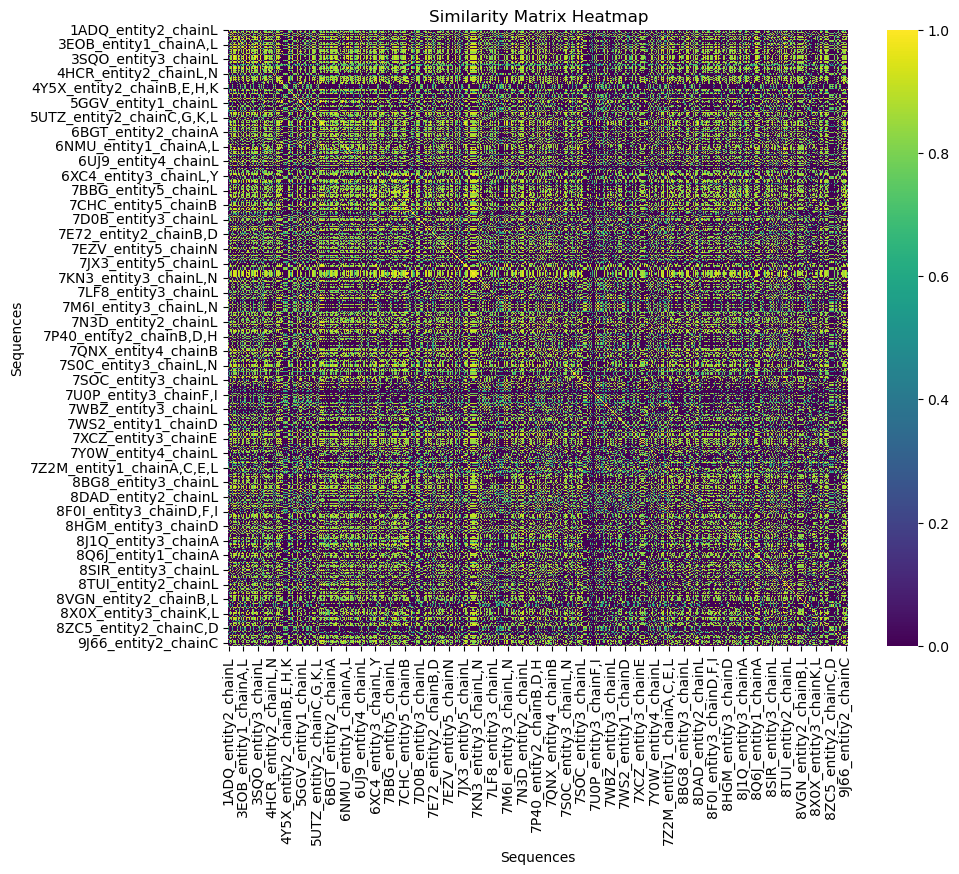

In [3]:
#visualising the similiarity matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, cmap='viridis')
plt.title("Similarity Matrix Heatmap")
plt.xlabel("Sequences")
plt.ylabel("Sequences")
plt.show()

#but is very confusing and does not provide enough information 

min = 0.0
max = 1.0
mean = 0.32227190842833886


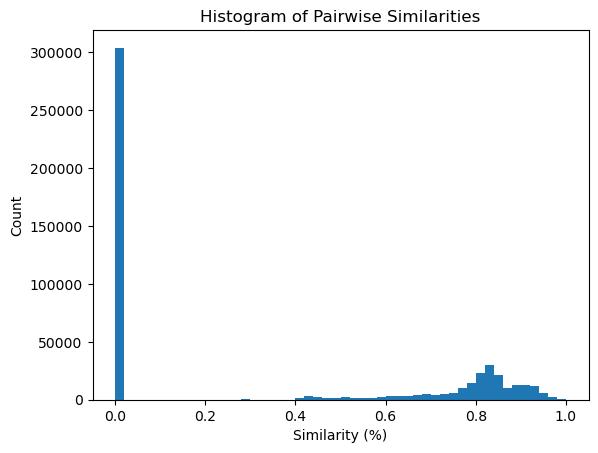

In [4]:
#inspecting similarity matrix to ensure it is correct
import matplotlib.pyplot as plt
import numpy as np

print(f"min = {similarity_matrix.min().min()}")
print(f"max = {similarity_matrix.max().max()}")
print(f"mean = {similarity_matrix.values.mean()}")

#upper triangle values excluding diagonal
sim_values = similarity_matrix.values[np.triu_indices_from(similarity_matrix, k=1)]

plt.hist(sim_values, bins=50)
plt.title("Histogram of Pairwise Similarities")
plt.xlabel("Similarity (%)")
plt.ylabel("Count")
plt.show()

min = 0.0
max = 1.0
mean = 0.6777280915716609


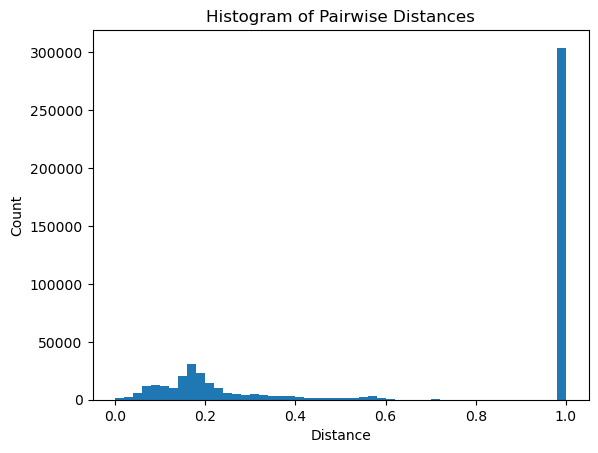

In [5]:
#makins distance matrix and inspecting it to be correct
import matplotlib.pyplot as plt
import numpy as np

distance_matrix = 1 - similarity_matrix
distance_matrix.to_csv("distance_matrix.csv")

#printing out the minimum, maximum, mean
print(f"min = {distance_matrix.values.min()}")
print(f"max = {distance_matrix.values.max()}")
print(f"mean = {distance_matrix.values.mean()}")

values = distance_matrix.values[np.triu_indices_from(distance_matrix.values, k=0)]
plt.hist(values, bins=50)
plt.title("Histogram of Pairwise Distances")
plt.xlabel("Distance")
plt.ylabel("Count")
plt.show()

Clusters: 2, Silhouette Score: 0.3219
Clusters: 3, Silhouette Score: 0.3260
Clusters: 4, Silhouette Score: 0.5209
Clusters: 5, Silhouette Score: 0.4749
Clusters: 6, Silhouette Score: 0.4497
Clusters: 7, Silhouette Score: 0.2835
Clusters: 8, Silhouette Score: 0.2436
Clusters: 9, Silhouette Score: 0.2187
Clusters: 10, Silhouette Score: 0.2469
Clusters: 11, Silhouette Score: 0.2431
Clusters: 12, Silhouette Score: 0.2006
Clusters: 13, Silhouette Score: 0.1554
Clusters: 14, Silhouette Score: 0.1648
Clusters: 15, Silhouette Score: 0.1449
Clusters: 16, Silhouette Score: 0.2121
Clusters: 17, Silhouette Score: 0.1968
Clusters: 18, Silhouette Score: 0.1868
Clusters: 19, Silhouette Score: 0.1538
Clusters: 20, Silhouette Score: 0.1577
Clusters: 21, Silhouette Score: 0.2084
Clusters: 22, Silhouette Score: 0.2223
Clusters: 23, Silhouette Score: 0.1976
Clusters: 24, Silhouette Score: 0.1721
Clusters: 25, Silhouette Score: 0.1551
Clusters: 26, Silhouette Score: 0.1539
Clusters: 27, Silhouette Score: 0

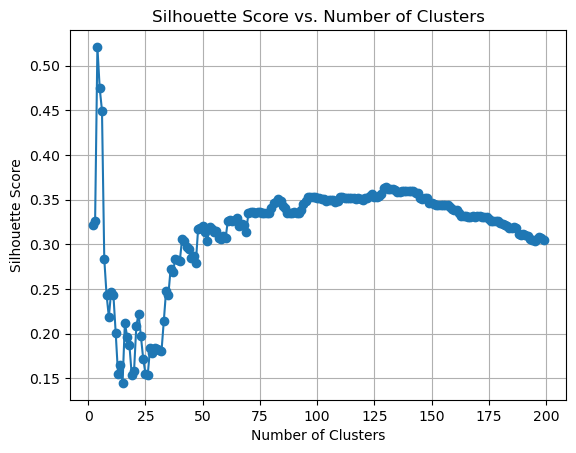

In [6]:
#before applying PCA, the best number of clusters should be found
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#different cluster counts are tried out
scores = []
for k in range(2, 200):
    clustering = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage='average')
    labels = clustering.fit_predict(distance_matrix.values)
    score = silhouette_score(distance_matrix.values, labels, metric='precomputed')
    scores.append((k, score))
    print(f"Clusters: {k}, Silhouette Score: {score:.4f}")

ks, s_scores = zip(*scores)
plt.plot(ks, s_scores, marker='o')
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

-> from the silhouette score, the closest value to 1 is achieved with 4 clusters, second best is around 130
-> try different methods, to estimate the best cluster number

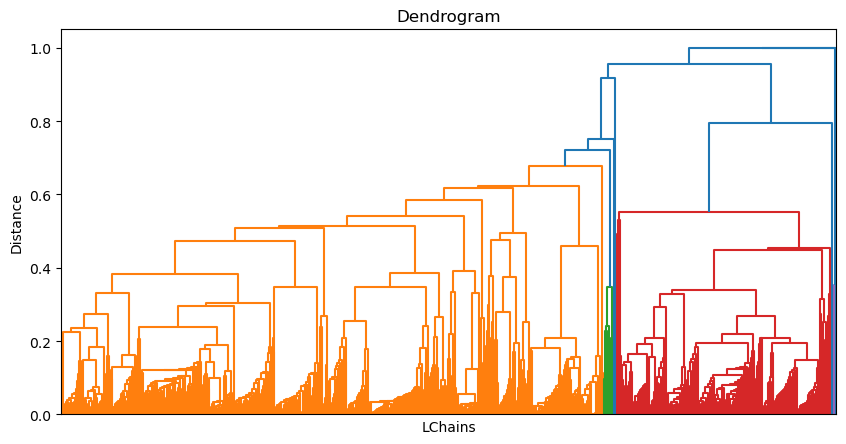

In [7]:
#dendogram visualisation 
from scipy.cluster.hierarchy import dendrogram, linkage

#distance matrix converted to condensed form
from scipy.spatial.distance import squareform
condensed_dist = squareform(distance_matrix.values)

linked = linkage(condensed_dist, method='average') #which linkage method is the best?

plt.figure(figsize=(10, 5))
dendrogram(linked, no_labels=True, distance_sort='descending')
plt.title("Dendrogram")
plt.xlabel("LChains")
plt.ylabel("Distance")
plt.show()


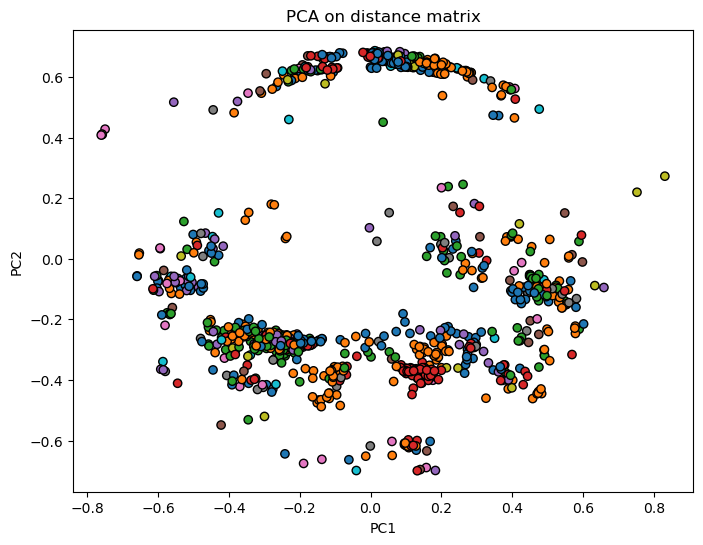

explained variance by each PC1 and PC2: [0.46285052 0.11742874]
total variance explained by PC1 and PC2: 58.03%


In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_plot = pca.fit_transform(distance_matrix.values)

plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=labels, cmap='tab10', edgecolor='k')
plt.title("PCA on distance matrix")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

#explaining the variance and total variance in percentage 
variance = pca.explained_variance_ratio_
print("explained variance by each PC1 and PC2:", variance)

total_variance = variance.sum() * 100
print(f"total variance explained by PC1 and PC2: {total_variance:.2f}%")

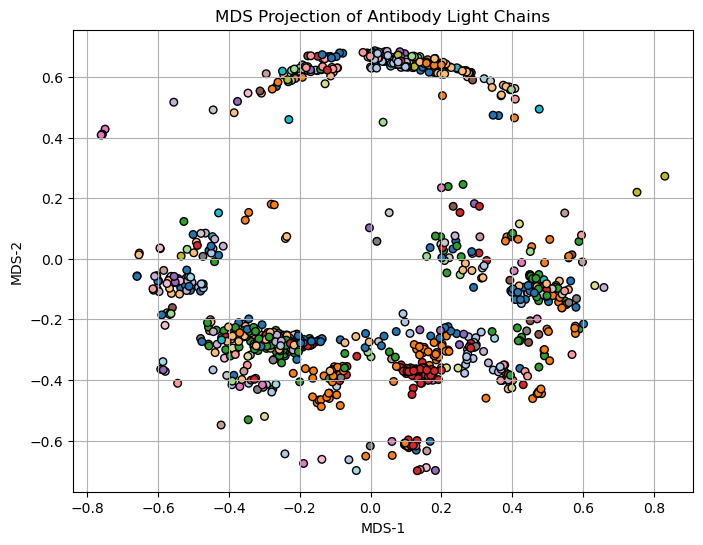

In [25]:
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

#dataframe is converted to numpy array, as MDS uses only arrays (similar to matrices)
distance_array = distance_matrix.values

#MDS = multidimentional scaling, alternative to PCA
mds = MDS(n_components=2, dissimilarity='precomputed', normalized_stress=False, n_init=4, random_state= 50)
mds_plot = mds.fit_transform(distance_array)

#clustering to colour
from sklearn.cluster import AgglomerativeClustering
n_clusters = k
labels = AgglomerativeClustering(n_clusters=n_clusters, metric='precomputed', linkage='average').fit_predict(distance_array)

#visualisation of MDS
plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=labels, cmap='tab20', s=30, edgecolor='k', marker='o')
plt.title("MDS Projection of Antibody Light Chains")
plt.xlabel("MDS-1")
plt.ylabel("MDS-2")
plt.grid(True)
plt.show()

to make sure, that clusters are meaningfull, other different clustering methods are gonna be used and compared, how similar the clusters in each method are


/home/barth/miniforge3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/barth/miniforge3/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/barth/miniforge3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/barth/miniforge3/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/barth/miniforge3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state.

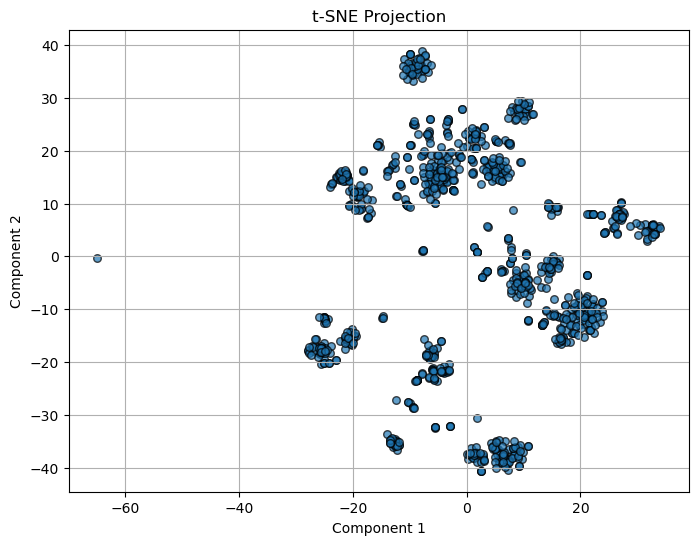

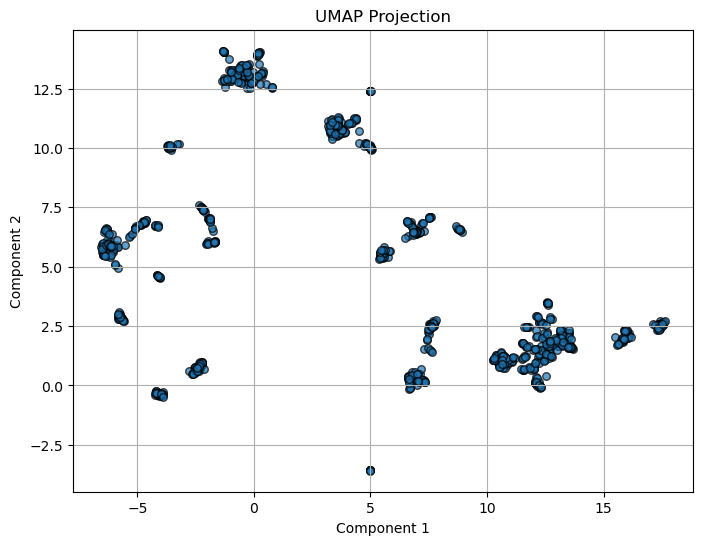

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
from umap import UMAP

#t-SNE clustering
tsne = TSNE(n_components=2, metric='precomputed', init='random', random_state= 50)
tsne_plot = tsne.fit_transform(distance_matrix.values)

#UMAP clustering 
umap = UMAP(n_components=2, metric='precomputed').fit_transform(distance_matrix.values)
umap_plot = umap.UMAP(n_components=2, metric='precomputed', random_state=42)

#function
def plot_template(coords, title):
    plt.figure(figsize=(8,6))
    plt.scatter(coords[:,0], coords[:,1], s=30, edgecolor='k', alpha=0.7)
    plt.title(title)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.grid(True)
    plt.show()

#t-SNE visualisation
plot_template(tsne_plot, "t-SNE Projection")

#UMAP visualisation
plot_template(umap_plot, "UMAP Projection")



i also need to find out how much clusters i want to use for every single comparison, and not only use the PCA cluster number

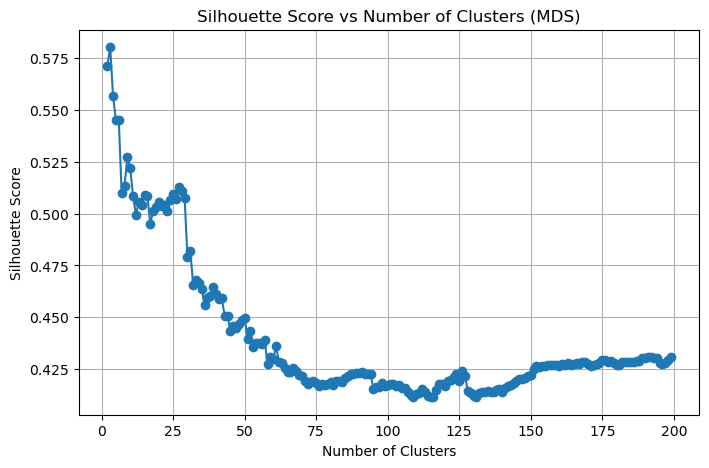


Best number of clusters for MDS: 3 with 54.51%


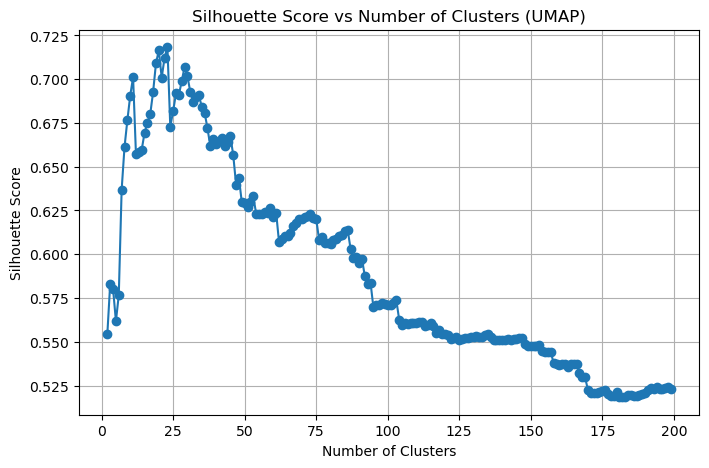


Best number of clusters for UMAP: 23 with 68.17%


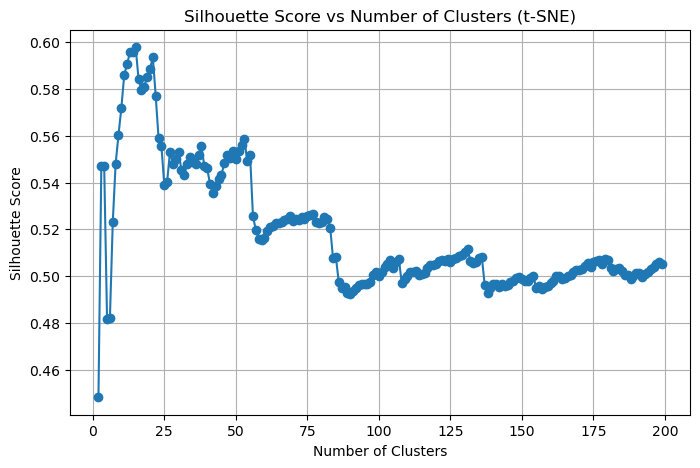


Best number of clusters for t-SNE: 15 with 57.95%


In [38]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import numpy as np

def cluster_number(embedding, method_name="embedding", cluster_range=range(2, 200)):
  
    scores = []
    for k in cluster_range:
        clustering = AgglomerativeClustering(n_clusters=k)
        labels = clustering.fit_predict(embedding)
        try:
            score = silhouette_score(embedding, labels)
            scores.append((k, score))
        except Exception as e:
            print(f"Failed at {k} clusters: {e}")
            continue

    # Plotting
    ks, sil_scores = zip(*scores)
    plt.figure(figsize=(8, 5))
    plt.plot(ks, sil_scores, marker='o')
    plt.title(f"Silhouette Score vs Number of Clusters ({method_name})")
    plt.xlabel("Number of Clusters")
    plt.ylabel("Silhouette Score")
    plt.grid(True)
    plt.show()

    # Best k
    best_k = ks[np.argmax(sil_scores)]
    best_score = sil_scores[best_k]
    
    print(f"\nBest number of clusters for {method_name}: {best_k} with {best_score * 100:.2f}%")
    return best_k


best_k_mds = cluster_number(mds_plot, method_name="MDS")
best_k_umap = cluster_number(umap_plot, method_name="UMAP")
best_k_tsne = cluster_number(tsne_plot, method_name="t-SNE")

In [43]:
from sklearn.cluster import AgglomerativeClustering

def pca_function(coords):
    return AgglomerativeClustering(n_clusters=4).fit_predict(coords)
pca_clusters = pca_function(pca_plot)

def mds_function(coords):
    return AgglomerativeClustering(n_clusters=best_k_mds).fit_predict(coords)
mds_clusters = mds_function(mds_plot)

def tsne_function(coords):
    return AgglomerativeClustering(n_clusters=best_k_tsne).fit_predict(coords)
tsne_clusters = tsne_function(tsne_plot)

def umap_function(coords):
    return AgglomerativeClustering(n_clusters=best_k_umap).fit_predict(coords)
umap_clusters = umap_function(umap_plot)


#comparison of all different clusterings using ARI = adjusted rand index, a similarity method between two clusterings [ARI = (RI - Expected_RI) / (max(RI) - Expected_RI)]
from sklearn.metrics import adjusted_rand_score

ari_pca_mds = adjusted_rand_score(pca_clusters, mds_clusters)
ari_pca_tsne = adjusted_rand_score(pca_clusters, tsne_clusters)
ari_pca_umap = adjusted_rand_score(pca_clusters, umap_clusters)

print(f"ARI PCA-MDS: {ari_pca_mds*100:.2f}")
print(f"ARI PCA-tSNE: {ari_pca_tsne*100:.2f}")
print(f"ARI PCA-UMAP: {ari_pca_umap*100:.2f}")

#the closer the number is to 1 -> the more similar the clusters came out

ARI PCA-MDS: 75.14
ARI PCA-tSNE: 18.35
ARI PCA-UMAP: 13.41
